In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
data = load_breast_cancer(as_frame = True)

In [4]:
df = data.frame

In [5]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
df.shape

(569, 31)

In [7]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [8]:
df.isna().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

<Axes: xlabel='target', ylabel='count'>

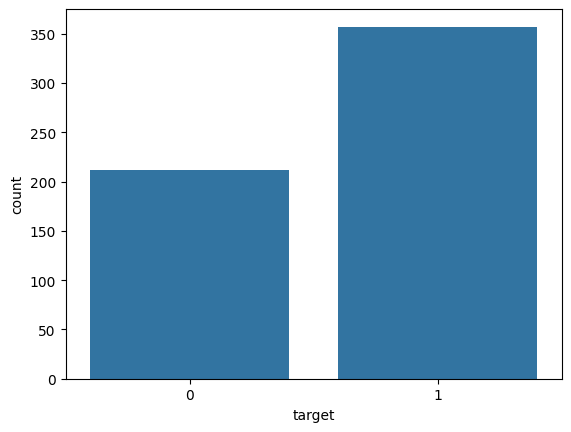

In [9]:
sns.countplot(x = df['target'])

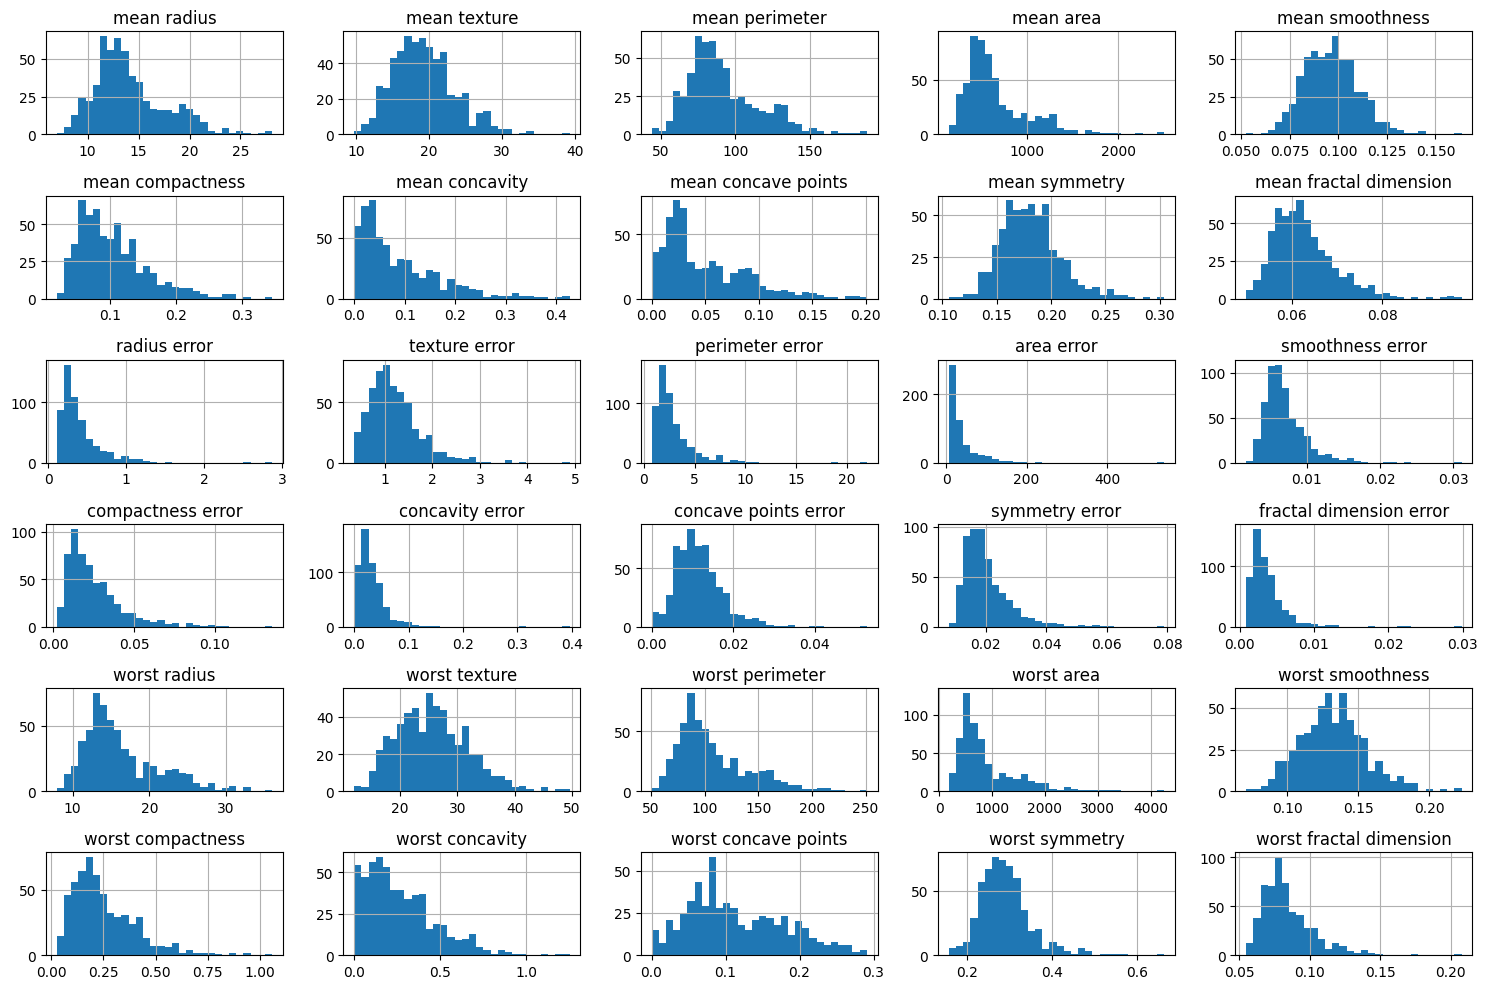

In [10]:
df.drop(columns = 'target').hist(figsize = (15, 10), bins = 30)
plt.tight_layout()
plt.show()

In [11]:
df.corr()['target'].sort_values(ascending = False)

target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0

In [12]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop('target', axis = 1)
y = df['target']

mi = mutual_info_classif(X, y, random_state = 42)
mi_Series = pd.Series(mi, index = X.columns).sort_values(ascending = False)

In [13]:
df_train = df.copy()

In [14]:
df_train.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [15]:
X = df_train.drop('target', axis = 1)
y = df_train['target']

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42)

In [19]:
scaler = StandardScaler()

In [20]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability = True, kernel = 'rbf')
}

In [22]:
result = []

In [23]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    result.append({
        'model': name,
        'accuracy': round(acc, 4),
        'f1': round(f1, 4)
    })

In [24]:
result

[{'model': 'Logistic Regression', 'accuracy': 0.9737, 'f1': 0.979},
 {'model': 'Naive Bayes', 'accuracy': 0.9649, 'f1': 0.9722},
 {'model': 'KNN', 'accuracy': 0.9474, 'f1': 0.9577},
 {'model': 'SVM', 'accuracy': 0.9825, 'f1': 0.9861}]

In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    SVC(max_iter=1000),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

scores.mean()

np.float64(0.9810159148793133)

In [26]:
top_10_features = mi_Series.head(10).index
X_reduced = X[top_10_features]

In [27]:
X_reduced.head()

,worst perimeter,worst area,worst radius,mean concave points,worst concave points,mean perimeter,mean concavity,mean radius,mean area,area error
0,184.60,2019.0,25.38,0.14710,0.2654,122.80,0.3001,17.99,1001.0,153.40
1,158.80,1956.0,24.99,0.07017,0.1860,132.90,0.0869,20.57,1326.0,74.08
2,152.50,1709.0,23.57,0.12790,0.2430,130.00,0.1974,19.69,1203.0,94.03
3,98.87,567.7,14.91,0.10520,0.2575,77.58,0.2414,11.42,386.1,27.23
4,152.20,1575.0,22.54,0.10430,0.1625,135.10,0.1980,20.29,1297.0,94.44


In [28]:
X_reduced.columns

Index(['worst perimeter', 'worst area', 'worst radius', 'mean concave points',
       'worst concave points', 'mean perimeter', 'mean concavity',
       'mean radius', 'mean area', 'area error'],
      dtype='object')

In [29]:
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(X_reduced, y, test_size = 0.2, random_state = 42)

In [30]:
scaler_reduced = StandardScaler()

In [46]:
X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced)
X_test_reduced_scaled = scaler_reduced.transform(X_test_reduced)

In [47]:
reduced_models = {
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability = True, kernel = 'rbf')
}

In [48]:
reduced_result = []

In [49]:
for name, model in reduced_models.items():
    model.fit(X_train_reduced_scaled, y_train_reduced)
    y_pred = model.predict(X_test_reduced_scaled)
    acc = accuracy_score(y_test_reduced, y_pred)
    f1 = f1_score(y_test_reduced, y_pred)
    reduced_result.append({
        'model': name,
        'accuracy': round(acc, 4),
        'f1': round(f1, 4)
    })

In [50]:
reduced_result

[{'model': 'Logistic Regression', 'accuracy': 0.9825, 'f1': 0.9859},
 {'model': 'Naive Bayes', 'accuracy': 0.9737, 'f1': 0.9793},
 {'model': 'KNN', 'accuracy': 0.9649, 'f1': 0.9718},
 {'model': 'SVM', 'accuracy': 0.9649, 'f1': 0.9722}]

In [55]:
# Using cross validation and hyperparameter tuning on Logistic Regression
scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_train_reduced_scaled,
    y_train_reduced,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", scores.round(2))
print("Mean Score:", scores.mean().round(2))
print("Standard Deviation:", scores.std().round(2))

Cross Validation Scores: [0.93 0.93 0.99 0.96 0.96]
Mean Score: 0.95
Standard Deviation: 0.02


In [56]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

model = LogisticRegression(max_iter = 1000)

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator = model,
    param_grid = param_grid,
    scoring = 'accuracy',
    cv = 5,
    n_jobs = -1
)

grid_search.fit(X_train_reduced_scaled, y_train_reduced)

# Best parameters
print('Best Parameters: ', grid_search.best_params_)

# Best cross validation score
print('Best Score: ', grid_search.best_score_)

Best Parameters:  {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Score:  0.9538461538461538


In [57]:
best_model = grid_search.best_estimator_
best_model.fit(X_train_reduced_scaled, y_train_reduced)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [58]:
from sklearn.metrics import accuracy_score, f1_score

y_pred = best_model.predict(X_test_reduced_scaled)

print("Test Accuracy:", accuracy_score(y_test_reduced, y_pred))
print("Test F1 Score:", f1_score(y_test_reduced, y_pred))

Test Accuracy: 0.9824561403508771
Test F1 Score: 0.9859154929577465


In [59]:
import joblib
joblib.dump(best_model, 'reduced_LR_model.pkl')
joblib.dump(scaler_reduced, 'reduced_scaler_LR.pkl')
joblib.dump(X_reduced.columns, 'reduced_columns_LR.pkl')

['reduced_columns_LR.pkl']